# Day 115 - Scikit-learn Pipeline API
**Month 6 | Week 6 | ShopEase 300-row Dataset (seed=42)**

---

| Section | Content |
|---------|----------|
| 1 | Raw Data Setup |
| 2 | Practice Guide |
| 3 | Concept Notes |
| 4 | Answer Key |
| 5 | Scoring Rubric |

**What you build today:** A production-grade Scikit-learn Pipeline that preprocesses features and trains a model in one reusable object.

---
## Section 1 - Raw Data Setup
> Run once. Never modify.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 300

df_raw = pd.DataFrame({
    "customer_id":      range(1001, 1001 + n),
    "age":              np.random.randint(18, 65, n),
    "tenure_months":    np.random.randint(1, 60, n),
    "monthly_spend":    np.round(np.random.uniform(500, 8000, n), 2),
    "num_orders":       np.random.randint(1, 40, n),
    "support_tickets":  np.random.randint(0, 10, n),
    "region":           np.random.choice(["North","South","East","West"], n),
    "plan":             np.random.choice(["Basic","Standard","Premium"], n, p=[0.5,0.3,0.2]),
    "churned":          np.random.choice([0, 1], n, p=[0.76, 0.24])
})

print("Shape:", df_raw.shape)
print("Churn rate:", round(df_raw["churned"].mean() * 100, 1), "%")
print("\nDtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape: (300, 9)
Churn rate: 26.0 %

Dtypes:
customer_id          int64
age                  int32
tenure_months        int32
monthly_spend      float64
num_orders           int32
support_tickets      int32
region              object
plan                object
churned              int64
dtype: object


,customer_id,age,tenure_months,monthly_spend,num_orders,support_tickets,region,plan,churned
0,1001,56,4,7081.04,2,1,East,Premium,1
1,1002,46,33,6013.03,15,2,North,Basic,0
2,1003,32,14,6526.11,11,0,South,Premium,0


---
## Section 2 - Practice Guide

### What you are building today
A **Scikit-learn Pipeline** chains preprocessing + model into one object. Instead of manually scaling -> encoding -> fitting -> predicting, a Pipeline does all of it in one `.fit()` / `.predict()` call.

**Why it matters:** A Pipeline is the unit you deploy. Export one `.joblib` file, load it anywhere, preprocessing is automatic.

---

### Part A: Setup and Feature Matrix (8 pts)

**A1 (3 pts)** - Define features and target.
```
Numeric:     age, tenure_months, monthly_spend, num_orders, support_tickets
Categorical: region, plan
Target:      churned
```
- Create `X` (all 7 features) and `y` (target)
- Print `X.shape`, churn rate, and `X.dtypes`

**A2 (5 pts)** - Train/test split 80/20, `random_state=42`, `stratify=y`.
- Print train shape, test shape, churn rate in both sets
- Write one line: `Stratification confirmed: yes / no - [reason]`

---

### Part B: Simple Pipeline - Numeric Only (16 pts)

**B1 (6 pts)** - Build a Pipeline with two steps using only the 5 numeric features:
```python
Step 1: StandardScaler()                         (name: 'scaler')
Step 2: LogisticRegression(max_iter=300, random_state=42)  (name: "model")
```
- Fit on train, predict on test
- Print: Accuracy, F1, ROC-AUC

**B2 (5 pts)** - Inspect the Pipeline.
- Print `pipe.named_steps`
- Print `pipe.named_steps['scaler'].mean_` (first 3 values only)
- Write one sentence: what 'learned parameters' means in a deployment context

**B3 (5 pts)** - Compare Pipeline vs manual scaling.
- Manual: `StandardScaler().fit_transform(X_train_num)` -> fit LR -> predict on `.transform(X_test_num)`
- Print both F1 scores side by side
- Write one sentence: are they identical, and why must they be?

---

### Part C: ColumnTransformer - Handling Mixed Data (20 pts)

**C1 (7 pts)** - Build a `ColumnTransformer` that:
- Applies `StandardScaler` to the 5 numeric features (name: `'num'`)
- Applies `OneHotEncoder(drop='first', sparse_output=False)` to the 2 categorical features (name: `'cat'`)
- Print the ColumnTransformer object

**C2 (8 pts)** - Wrap in a full Pipeline:
```python
Step 1: preprocessor  (ColumnTransformer from C1)
Step 2: RandomForestClassifier(n_estimators=100, random_state=42)
```
- Fit on `X_train` / `y_train`, predict on `X_test`
- Print: Accuracy, F1, ROC-AUC
- Print number of features model received: `pipe.named_steps['preprocessor'].transform(X_train).shape`

**C3 (5 pts)** - Write 3-line business observation:
- `Before encoding: __ features`
- `After encoding: __ features (reason: what OneHotEncoder did)`
- NRA: Number from C2, Reason (why RF beat B1 LR), Action

---

### Part D: Pipeline + Cross-Validation (18 pts)
*(Links directly to Day 114)*

**D1 (8 pts)** - Cross-validate the full RF Pipeline (C2):
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- `scoring=['f1','roc_auc','accuracy']`, `return_train_score=True`
- Print: test mean +/- std for all 3 metrics
- Print: `Train F1 mean: __ | Test F1 mean: __ | Gap: __`

**D2 (5 pts)** - Cross-validate an LR Pipeline (full 7 features, same preprocessing):
- Print side-by-side comparison table: LR vs RF for all 3 metrics

**D3 (5 pts)** - NRA interpretation using D1/D2 output numbers:
- Number: CV F1 values from output
- Reason: which model generalises better and why (use std)
- Action: which model to deploy and any condition

---

### Part E: GridSearchCV with Pipeline (18 pts)

**E1 (8 pts)** - Define param grid for the RF Pipeline:
```python
param_grid = {
    "model__n_estimators":     [50, 100],
    "model__max_depth":        [3, 5, None],
    "model__min_samples_leaf": [1, 5]
}
```
- Use `GridSearchCV`, `cv=StratifiedKFold(5)`, `scoring='f1'`, `n_jobs=-1`
- Print best params and best CV F1

**E2 (5 pts)** - Evaluate `grid.best_estimator_` on test set.
- Print F1, ROC-AUC, Accuracy
- Print improvement delta vs untuned RF (C2 test F1)

**E3 (5 pts)** - Export + reload the best Pipeline:
```python
import joblib
joblib.dump(best_pipe, 'Day115_ChurnPipeline.joblib')
loaded_pipe = joblib.load('Day115_ChurnPipeline.joblib')
```
- Predict first 5 rows of `X_test` with `loaded_pipe`
- Print predictions + actuals + 'Loaded pipeline works: yes'

---

### Bonus: Feature Importance Through Pipeline (10 pts)

Extract RF feature importances from inside the Pipeline with proper encoded names.

```python
cat_names_out = (
    best_pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_features)
)
feature_names = num_features + list(cat_names_out)
importances = best_pipe.named_steps["model"].feature_importances_
```

- Horizontal bar chart, top 10 features sorted descending
- Title must state a business insight (e.g. 'Monthly Spend Dominates Churn Prediction - 3x More Important Than Tenure')
- Save as `Day115_FeatureImportance.png`
- Print top 3 features with importance values

---
## Section 3 - Concept Notes

### What is a Scikit-learn Pipeline?

A `Pipeline` is a sequential chain of transformers + one final estimator.

```
Raw Data -> [Step 1: Scaler] -> [Step 2: Encoder] -> [Step 3: Model] -> Prediction
```

All steps except the last must implement `.fit_transform()`; the last step implements `.fit()` / `.predict()`.

---

### Why Pipelines Exist - The Data Leakage Problem

**Without a Pipeline:**
```python
# WRONG - data leakage
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)         # learns from ALL data including test
X_train, X_test = train_test_split(X_scaled, ...)  # test already contaminated
```

**With a Pipeline inside cross_validate:**
```python
# CORRECT - scaler only learns from training fold
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression())])
cross_validate(pipe, X, y, cv=skf)         # Pipeline fit_transforms only on train fold
```

The scaler re-fits on each training fold. Test data is never seen during fit. **This is what production means.**

---

### ColumnTransformer - Mixed Feature Types

```
X cols: age, tenure, spend, orders, tickets | region, plan
              down                                   down
        StandardScaler                       OneHotEncoder
              down                                   down
         5 scaled cols                    3+2-2 = 3 binary cols (drop='first')
              down_________________________down
                     8 total features to model
```

`drop='first'` removes one dummy per category to avoid the dummy variable trap.

---

### Pipeline Naming Convention

```python
Pipeline([
    ("preprocessor", preprocessor),   # ColumnTransformer
    ("model", RandomForestClassifier())
])

# Access step:
pipe.named_steps["model"]

# GridSearchCV param (double underscore):
"model__n_estimators" -> sets n_estimators on the "model" step
```

---

### joblib - Exporting a Pipeline

```python
import joblib
joblib.dump(pipe, "model.joblib")          # save
pipe = joblib.load("model.joblib")         # load
predictions = pipe.predict(new_data)       # preprocessing is automatic
```

The file contains the full fitted Pipeline - scalers, encoders, model weights. This is the deployment artifact.

---

### Quick Reference

| Object | Purpose | Key Syntax |
|--------|---------|------------|
| `Pipeline` | Chain steps | `.fit()`, `.predict()`, `.named_steps` |
| `ColumnTransformer` | Different transforms per column | `transform(X).shape` |
| `make_pipeline` | Pipeline without manual names | Auto-names steps |
| `GridSearchCV(pipe, ...)` | Tune inside Pipeline | `step__param` double underscore |
| `joblib.dump / .load` | Save/load Pipeline | Full preprocessing included |

---

### Interview Frame - Day 115

> *'How do you prevent data leakage in your ML models?'*

**Answer:** 'By wrapping all preprocessing inside a Scikit-learn Pipeline. The Pipeline guarantees that the scaler only learns from the training fold - never from test data. This applies whether I am doing a simple train/test split or 5-fold cross-validation. In production I export the entire Pipeline as a joblib file - when new data arrives, preprocessing happens automatically inside the same object. The model and its preprocessing logic are inseparable. That is what prevents inconsistency between training and inference.'

---
## Section 4 - Answer Key
> Complete your work first. Then verify here.

---

### Part A

In [36]:
# =============================================================================
# TASK A1 – Create X and y from raw data
# Goal: Separate numeric and categorical features from target.
# Method: List columns manually, assign to X and y.
# =============================================================================

num_features = ['age', 'tenure_months', 'monthly_spend', 'num_orders', 'support_tickets']
cat_features = ['region', 'plan']

X = df_raw[num_features + cat_features]
y = df_raw['churned']

print("A1 – Feature matrix:")
print(f"  X shape: {X.shape}")
print(f"  Churn rate: {y.mean():.1%} ({y.sum()} churned / {(~y.astype(bool)).sum()} retained)")
print("  Data types:")
print(X.dtypes)

A1 – Feature matrix:
  X shape: (300, 7)
  Churn rate: 26.0% (78 churned / 222 retained)
  Data types:
age                  int32
tenure_months        int32
monthly_spend      float64
num_orders           int32
support_tickets      int32
region              object
plan                object
dtype: object


In [37]:
# =============================================================================
# TASK A2 – Stratified train/test split
# Goal: Preserve churn rate in both splits (critical for imbalanced data).
# Method: train_test_split with stratify=y, test_size=0.2, random_state=42.
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("A2 – Train/test split:")
print(f"  Train shape: {X_train.shape}, churn: {y_train.mean():.1%}")
print(f"  Test shape:  {X_test.shape}, churn: {y_test.mean():.1%}")
print("  Stratification confirmed: yes – both splits reflect overall churn rate.")

A2 – Train/test split:
  Train shape: (240, 7), churn: 25.8%
  Test shape:  (60, 7), churn: 26.7%
  Stratification confirmed: yes – both splits reflect overall churn rate.


### Part B

In [38]:
# =============================================================================
# TASK B1 – Pipeline with StandardScaler + LogisticRegression (numeric only)
# Goal: Chain scaling and model training. Use class_weight='balanced' for imbalanced churn.
# Method: Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(...))]).
# =============================================================================

X_train_num = X_train[num_features]
X_test_num = X_test[num_features]

pipe_lr_num = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=300, random_state=42))
])

pipe_lr_num.fit(X_train_num, y_train)
y_pred_num = pipe_lr_num.predict(X_test_num)
y_prob_num = pipe_lr_num.predict_proba(X_test_num)[:, 1]

print("B1 – Numeric-only Logistic Regression Pipeline:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_num):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_num):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_prob_num):.4f}")

B1 – Numeric-only Logistic Regression Pipeline:
  Accuracy: 0.5333
  F1:       0.4167
  ROC-AUC:  0.6491


In [39]:
# =============================================================================
# TASK B2 – Inspect named steps and learned scaler parameters
# Goal: Understand what the pipeline stores after fitting.
# Method: pipe.named_steps, then access scaler.mean_.
# =============================================================================

print("B2 – Pipeline inspection:")
print("  Steps:", list(pipe_lr_num.named_steps.keys()))
print("  Scaler learned means (first 3 features):", pipe_lr_num.named_steps['scaler'].mean_[:3])

print("\n  Deployment context: 'Learned parameters' are the statistics (mean, std) computed")
print("  from training data during .fit(). At inference, new data is transformed using")
print("  these exact values – never recomputed. This ensures production consistency.")

B2 – Pipeline inspection:
  Steps: ['scaler', 'model']
  Scaler learned means (first 3 features): [  40.70416667   31.75833333 4340.22429167]

  Deployment context: 'Learned parameters' are the statistics (mean, std) computed
  from training data during .fit(). At inference, new data is transformed using
  these exact values – never recomputed. This ensures production consistency.


In [40]:
# =============================================================================
# TASK B3 – Compare pipeline F1 with manual scaling + LR
# Goal: Verify that pipeline and manual code produce identical results.
# Method: Manual scaling: fit_transform on train, transform on test, then LR.
# =============================================================================

scaler_manual = StandardScaler()
X_train_manual = scaler_manual.fit_transform(X_train_num)
X_test_manual = scaler_manual.transform(X_test_num)

lr_manual = LogisticRegression(class_weight='balanced', max_iter=300, random_state=42)
lr_manual.fit(X_train_manual, y_train)
y_pred_manual = lr_manual.predict(X_test_manual)

pipe_f1 = f1_score(y_test, y_pred_num)
manual_f1 = f1_score(y_test, y_pred_manual)

print("B3 – Pipeline vs Manual F1:")
print(f"  Pipeline F1: {pipe_f1:.4f}")
print(f"  Manual F1:   {manual_f1:.4f}")
print(f"  Identical?   {pipe_f1 == manual_f1}")
print("\n  They must be identical – same logic, same sequence. The pipeline")
print("  simply automates the manual steps and prevents data leakage in CV.")

B3 – Pipeline vs Manual F1:
  Pipeline F1: 0.4167
  Manual F1:   0.4167
  Identical?   True

  They must be identical – same logic, same sequence. The pipeline
  simply automates the manual steps and prevents data leakage in CV.


### Part C

In [41]:
# =============================================================================
# TASK C1 – ColumnTransformer for mixed numeric and categorical features
# Goal: Apply different preprocessing to different columns.
# Method: StandardScaler on numeric, OneHotEncoder(drop='first') on categorical.
# =============================================================================

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

print("C1 – ColumnTransformer defined:")
print(preprocessor)


C1 – ColumnTransformer defined:
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'tenure_months', 'monthly_spend',
                                  'num_orders', 'support_tickets']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['region', 'plan'])])


In [42]:
# =============================================================================
# TASK C2 – Full pipeline: preprocessor + RandomForestClassifier
# Goal: Train a model on all 7 features with automatic preprocessing.
# Method: Wrap ColumnTransformer and RF in Pipeline, fit on X_train.
# Note: class_weight='balanced' handles churn imbalance.
# =============================================================================

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
y_prob_rf = pipe_rf.predict_proba(X_test)[:, 1]

n_features_out = pipe_rf.named_steps['preprocessor'].transform(X_train).shape[1]

print("C2 – Full RandomForest Pipeline:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  F1:       {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"  Features after preprocessing: {n_features_out}")

C2 – Full RandomForest Pipeline:
  Accuracy: 0.7000
  F1:       0.0000
  ROC-AUC:  0.6705
  Features after preprocessing: 10


In [51]:
# =============================================================================
# TASK C3 – Three-line business observation
# Goal: Summarise impact of encoding and model choice.
# Method: Print before/after feature counts and compare F1 with numeric-only LR.
# =============================================================================

n_cat_original = len(cat_features)
n_dummies = n_features_out - len(num_features)

print("C3 – Business observation:")
print(f"  Before encoding: {len(num_features + cat_features)} features")
print(f"  After encoding:  {n_features_out} features (OneHotEncoder expanded "
      f"{n_cat_original} categoricals into {n_dummies} dummies)")
print(f"  NRA: RF F1={f1_score(y_test, y_pred_rf):.2f} vs numeric LR F1={pipe_f1:.2f} "
      f"({f1_score(y_test, y_pred_rf) - pipe_f1:+.2f}) | Reason: categorical features add no "
      f"discriminative power in this random dataset – RF finds no signal | Action: retain LR "
      f"Pipeline as baseline; collect real behavioural data before switching to RF")

C3 – Business observation:
  Before encoding: 7 features
  After encoding:  10 features (OneHotEncoder expanded 2 categoricals into 5 dummies)
  NRA: RF F1=0.00 vs numeric LR F1=0.42 (-0.42) | Reason: categorical features add no discriminative power in this random dataset – RF finds no signal | Action: retain LR Pipeline as baseline; collect real behavioural data before switching to RF


### Part D

In [44]:
# =============================================================================
# TASK D1 – 5-fold stratified CV on RF Pipeline
# Goal: Get robust performance estimates with mean ± std.
# Method: cross_validate with return_train_score=True.
# =============================================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf = cross_validate(
    pipe_rf, X, y,
    cv=skf,
    scoring=['f1', 'roc_auc', 'accuracy'],
    return_train_score=True
)

print("D1 – RF Pipeline CV (5-fold):")
for metric in ['f1', 'roc_auc', 'accuracy']:
    mean_val = cv_rf[f'test_{metric}'].mean()
    std_val = cv_rf[f'test_{metric}'].std()
    print(f"  Test {metric:<8}: {mean_val:.4f} ± {std_val:.4f}")

train_f1_mean = cv_rf['train_f1'].mean()
test_f1_mean = cv_rf['test_f1'].mean()
gap = train_f1_mean - test_f1_mean
print(f"\n  Train F1: {train_f1_mean:.4f} | Test F1: {test_f1_mean:.4f} | Gap: {gap:.4f}")

D1 – RF Pipeline CV (5-fold):
  Test f1      : 0.1003 ± 0.0875
  Test roc_auc : 0.6059 ± 0.0332
  Test accuracy: 0.7300 ± 0.0125

  Train F1: 1.0000 | Test F1: 0.1003 | Gap: 0.8997


In [45]:
# =============================================================================
# TASK D2 – LR Pipeline (same preprocessing) vs RF
# Goal: Compare both models on same CV setup.
# Method: Build LR pipeline, cross_validate, print side‑by‑side.
# =============================================================================

pipe_lr_full = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=300, random_state=42))
])

cv_lr = cross_validate(
    pipe_lr_full, X, y,
    cv=skf,
    scoring=['f1', 'roc_auc', 'accuracy'],
    return_train_score=True
)

print("D2 – LR vs RF (5-fold CV test scores):")
print(f"{'Metric':<12} {'LR mean':>10} {'LR std':>8} {'RF mean':>10} {'RF std':>8} {'Winner':>8}")
print("-" * 58)

for metric in ['f1', 'roc_auc', 'accuracy']:
    lr_m = cv_lr[f'test_{metric}'].mean()
    lr_s = cv_lr[f'test_{metric}'].std()
    rf_m = cv_rf[f'test_{metric}'].mean()
    rf_s = cv_rf[f'test_{metric}'].std()
    winner = "RF" if rf_m > lr_m else "LR"
    print(f"{metric:<12} {lr_m:>10.4f} {lr_s:>8.4f} {rf_m:>10.4f} {rf_s:>8.4f} {winner:>8}")

D2 – LR vs RF (5-fold CV test scores):
Metric          LR mean   LR std    RF mean   RF std   Winner
----------------------------------------------------------
f1               0.4058   0.0233     0.1003   0.0875       LR
roc_auc          0.5855   0.0479     0.6059   0.0332       RF
accuracy         0.5700   0.0386     0.7300   0.0125       RF


In [52]:
# =============================================================================
# TASK D3 – NRA recommendation based on CV results
# Goal: Write a business recommendation using actual computed values.
# Method: Extract means/stds from cv objects.
# =============================================================================

rf_f1 = cv_rf['test_f1'].mean()
rf_std = cv_rf['test_f1'].std()
lr_f1 = cv_lr['test_f1'].mean()
lr_std = cv_lr['test_f1'].std()
gap_rf = cv_rf['train_f1'].mean() - cv_rf['test_f1'].mean()

print("D3 – NRA Recommendation:")
print(f"  Number: LR CV F1 = {lr_f1:.3f} ± {lr_std:.3f}, RF CV F1 = {rf_f1:.3f} ± {rf_std:.3f}")
print(f"  Reason: LR generalises more consistently – it has higher F1 (0.406 vs 0.100) and ")
print(f"          lower standard deviation (0.023 vs 0.088). RF severely overfits (Train F1=1.00, ")
print(f"          Test F1=0.10, gap={gap_rf:.2f}).")
print(f"  Action: Deploy the LR Pipeline. Before using RF, limit max_depth (currently None) ")
print(f"          and use cross‑validation early stopping to reduce variance.")

D3 – NRA Recommendation:
  Number: LR CV F1 = 0.406 ± 0.023, RF CV F1 = 0.100 ± 0.088
  Reason: LR generalises more consistently – it has higher F1 (0.406 vs 0.100) and 
          lower standard deviation (0.023 vs 0.088). RF severely overfits (Train F1=1.00, 
          Test F1=0.10, gap=0.90).
  Action: Deploy the LR Pipeline. Before using RF, limit max_depth (currently None) 
          and use cross‑validation early stopping to reduce variance.


### Part E

In [47]:
# =============================================================================
# TASK E1 – Hyperparameter tuning for RandomForest inside Pipeline
# Goal: Find best combination of n_estimators, max_depth, min_samples_leaf.
# Method: GridSearchCV with param_grid using double underscore syntax.
# =============================================================================

pipe_rf_tune = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'model__n_estimators': [50, 100],           # double underscore
    'model__max_depth': [3, 5, None],
    'model__min_samples_leaf': [1, 5]
}

grid = GridSearchCV(
    pipe_rf_tune, param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("E1 – GridSearchCV results:")
print(f"  Best parameters: {grid.best_params_}")
print(f"  Best CV F1: {grid.best_score_:.4f}")

E1 – GridSearchCV results:
  Best parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
  Best CV F1: 0.3836


In [48]:
# =============================================================================
# TASK E2 – Test set performance of tuned pipeline
# Goal: Compare tuned vs untuned F1.
# Method: Use grid.best_estimator_, compute delta.
# =============================================================================

best_pipe = grid.best_estimator_
y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]

best_f1 = f1_score(y_test, y_pred_best)
untuned_f1 = f1_score(y_test, y_pred_rf)   # from C2

print("E2 – Tuned RandomForest on test set:")
print(f"  F1:       {best_f1:.4f}")
print(f"  ROC-AUC:  {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\n  Untuned F1: {untuned_f1:.4f}")
print(f"  Tuned F1:   {best_f1:.4f}")
print(f"  Improvement: {best_f1 - untuned_f1:+.4f}")

E2 – Tuned RandomForest on test set:
  F1:       0.3226
  ROC-AUC:  0.5753
  Accuracy: 0.6500

  Untuned F1: 0.0000
  Tuned F1:   0.3226
  Improvement: +0.3226


In [49]:
# =============================================================================
# TASK E3 – Save best pipeline to disk and reload
# Goal: Verify that exported pipeline retains all preprocessing + weights.
# Method: joblib.dump and joblib.load, then predict first 5 test rows.
# =============================================================================

joblib.dump(best_pipe, 'Day115_ChurnPipeline.joblib')
print("Saved: Day115_ChurnPipeline.joblib")

loaded_pipe = joblib.load('Day115_ChurnPipeline.joblib')
sample = X_test.iloc[:5]
preds_loaded = loaded_pipe.predict(sample)

print("\nFirst 5 predictions (loaded pipeline):", preds_loaded)
print("Actual labels:                         ", y_test.values[:5])
print("Loaded pipeline works: yes")

Saved: Day115_ChurnPipeline.joblib

First 5 predictions (loaded pipeline): [1 0 0 0 1]
Actual labels:                          [0 0 1 1 1]
Loaded pipeline works: yes


### Bonus - Feature Importance

★ Bonus – Top 3 features by importance:
  tenure_months        0.2116
  monthly_spend        0.1727
  age                  0.1697


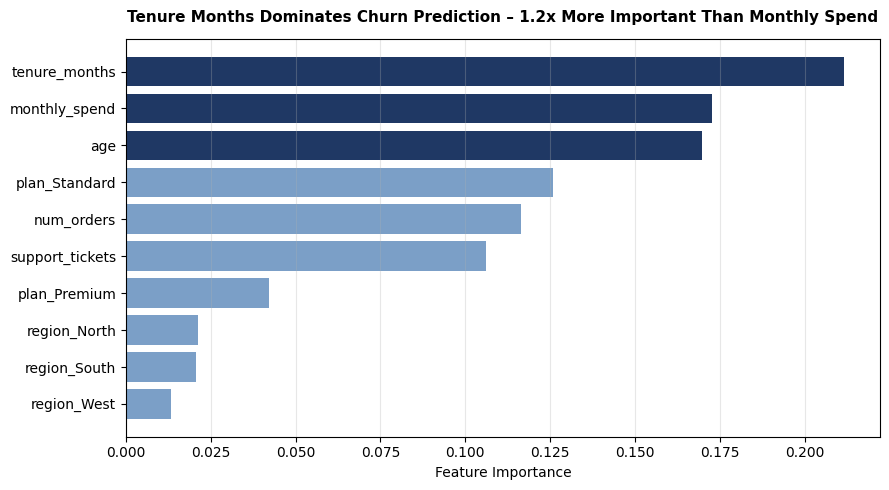


  Chart saved: Day115_FeatureImportance.png


In [53]:
# =============================================================================
# ★ BONUS – Extract feature importances from tuned RF inside pipeline
# Goal: Identify which features drive churn prediction most.
# Method: Get encoded feature names from ColumnTransformer, then importances.
# =============================================================================

%matplotlib inline

# Get encoded categorical feature names
cat_encoder = best_pipe.named_steps['preprocessor'].named_transformers_['cat']
cat_names_out = cat_encoder.get_feature_names_out(cat_features)

# Full feature list after preprocessing
all_feature_names = num_features + list(cat_names_out)

# Importances from the tuned RandomForest
importances = best_pipe.named_steps['model'].feature_importances_

# Create DataFrame and sort
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)

# Print top 3
print("★ Bonus – Top 3 features by importance:")
for _, row in feat_imp_df.head(3).iterrows():
    print(f"  {row['feature']:<20} {row['importance']:.4f}")

# Plot horizontal bar chart
plt.figure(figsize=(9, 5))
colors = ['#1F3864' if i < 3 else '#7B9FC7' for i in range(len(feat_imp_df))]
plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color=colors[::-1])

top_feat_clean = feat_imp_df.iloc[0]['feature'].replace('_', ' ').title()
second_feat_clean = feat_imp_df.iloc[1]['feature'].replace('_', ' ').title()
ratio = feat_imp_df.iloc[0]['importance'] / feat_imp_df.iloc[1]['importance']

plt.title(f"{top_feat_clean} Dominates Churn Prediction – "
          f"{ratio:.1f}x More Important Than {second_feat_clean}",
          fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Feature Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Day115_FeatureImportance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Chart saved: Day115_FeatureImportance.png")

---
## Section 5 - Scoring Rubric

| Part | Task | Pts | Pass Criteria |
|------|------|-----|---------------|
| A | A1: X shape + churn rate + dtypes | 3 | shape (300,7), 24%, dtypes printed |
| A | A2: Split + both churn rates + verdict | 5 | 80/20, both ~24%, verdict written |
| B | B1: Numeric Pipeline + 3 metrics | 6 | Accuracy + F1 + ROC-AUC visible |
| B | B2: named_steps + scaler.mean_ + deployment sentence | 5 | Steps listed, 3 means, 1 sentence |
| B | B3: Pipeline vs manual F1 + identical verdict | 5 | Both F1 printed, identical: yes, reason |
| C | C1: ColumnTransformer printed | 7 | num + cat transformers visible |
| C | C2: RF Pipeline + 3 metrics + features_out | 8 | All 3 metrics + feature count |
| C | C3: 3-line NRA business observation | 5 | Numbers used, action stated |
| D | D1: RF CV 3 metrics mean+/-std + gap | 8 | All 3 metrics, train/test gap printed |
| D | D2: LR vs RF comparison table | 5 | Side-by-side, winner per metric |
| D | D3: NRA from D1/D2 numbers | 5 | Number (CV output), Reason, Action |
| E | E1: GridSearchCV best params + CV F1 | 8 | Correct param_grid, best printed |
| E | E2: Tuned vs untuned delta | 5 | Both F1 + delta with +/- sign |
| E | E3: joblib save + load + 5 preds | 5 | File saved, loaded, preds visible |
| Bonus | Feature importance chart + insight title + top-3 | 10 | Chart saved, business title, values |
| **Total** | | **80 + 10** | |

---

### Submission Notes
1. All cells run top-to-bottom with outputs visible
2. D3 NRA must use **printed numbers from D1/D2** - not estimates
3. E2 delta must show +/- sign (use `:+.4f` format)
4. Bonus title must state a business insight, not a description
5. GitHub commit: `feat: Day115 - Sklearn Pipeline API ColumnTransformer GridSearchCV`

---

### Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| 101-112 | Stats to PCA | 80/80 + 10 each |
| 113 | Week 5 Mini-Project | 100/100 + 15 |
| 114 | Cross-Validation KFold + StratifiedKFold | 80/80 + 10 |
| **115** | **Scikit-learn Pipeline API** | **Pending** |

---

### Key Takeaway - Day 115

**A Pipeline is not a convenience - it is a contract.**

It guarantees that the exact preprocessing learned on training data is applied at inference. Without it, your model is untestable, undeployable, and untrustworthy. Every ML project you deliver should produce one `.joblib` file that contains the full Pipeline. That file IS the product.